In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except:
    ! pip install statsmodels
    from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression

#### Functions

In [2]:
class GenericCleaning:
    def __init__(self):
        pass
    def fit(self, X):
        print('Generic cleaning...')
        pass
    def transform(self, X):
        print('Generic cleaning...')
        X = X.copy()
        # replace terms w val 0
        X['term_months'] = X['term_months'].replace(0, np.nan)
        # clean channel
        X['channel'] = X['channel'].str.lower().str.strip()
        return X

In [3]:
class FillMissing:
    def __init__(self, dict_fillna):
        self.dict_fillna = dict_fillna
    def fit(self, X):
        print('Calculating imputation value...')
        dict_impute = {}
        for key, val in tqdm(self.dict_fillna.items()):
            if val == 'max':
                val_impute = X[key].max()
            elif val == 'min':
                val_impute = X[key].min()
            elif val == 'missing':
                val_impute = 'missing'
            # assign
            dict_impute[key] = val_impute
        # save to object
        self.dict_impute = dict_impute
    def transform(self, X):
        print('Filling missing values...')
        X = X.copy()
        dict_impute = self.dict_impute
        list_cols = list(X.columns)
        dict_impute = {key: val for key, val in dict_impute.items() if key in list_cols}
        # impute
        for key, val in tqdm(dict_impute.items()):
            X[key] = X[key].fillna(val)
        return X

In [4]:
class FeatureEngineering:
    def __init__(self):
        pass
    def fit(self, X):
        print('Feature engineering...')
        # get unique channels
        list_channels_unique = list(X['channel'].unique())
        # save to object
        self.list_channels_unique = list_channels_unique
    def transform(self, X):
        print('Feature engineering...')
        X = X.copy()
        # log income
        X['ENG-stated_income_log'] = np.log1p(X['stated_income'])
        # loan to income
        X['ENG-loan_to_income'] = X['loan_amount'] / (X['stated_income'] + 1)
        # dummy channel (rm first item from list)
        for channel_unique in self.list_channels_unique[1:]:
            X[f'ENG-channel_{channel_unique}'] = (X['channel'] == channel_unique).astype(int)
        return X

In [5]:
class ScaleFeatures:
    def __init__(self, list_cols_scale):
        self.list_cols_scale = list_cols_scale
    def fit(self, X):
        print('Calculating mean and standard deviations...')
        dict_scale = {}
        for col in self.list_cols_scale:
            flt_mn = X[col].mean()
            flt_sd = X[col].std(ddof=0)
            if flt_sd == 0:
                flt_sd = 1.0
            dict_scale[col] = {'mn': flt_mn, 'sd': flt_sd}
        self.dict_scale = dict_scale
    def transform(self, X):
        print('Scaling features...')
        X = X.copy()
        dict_scale = self.dict_scale
        list_cols = list(X.columns)
        dict_scale = {key: val for key, val in dict_scale.items() if key in list_cols}
        # scale
        for key, val in dict_scale.items():
            X[key] = (X[key] - val['mn']) / val['sd']
        return X

In [6]:
class PreprocessingModel:
    def __init__(self, list_cls_transformers):
        self.list_cls_transformers = list_cls_transformers
    def transform(self, X):
        for cls_transformer in self.list_cls_transformers:
            X = cls_transformer.transform(X)
        return X

In [7]:
def fit_logistic_model(X_train, y_train, X_valid, y_valid, X_test, y_test):
    # init
    cls_model_inference = LogisticRegression(
        fit_intercept=True,
        random_state=42,
    )
    
    # fit
    cls_model_inference.fit(X_train, y_train)
    
    # predictions
    y_hat_train = cls_model_inference.predict_proba(X_train)[:, 1]
    y_hat_valid = cls_model_inference.predict_proba(X_valid)[:, 1]
    y_hat_test = cls_model_inference.predict_proba(X_test)[:, 1]
    
    # evaluate
    flt_roc_auc_train = roc_auc_score(y_train, y_hat_train)
    flt_roc_auc_valid = roc_auc_score(y_valid, y_hat_valid)
    flt_roc_auc_test = roc_auc_score(y_test, y_hat_test)
    
    flt_pr_auc_train = average_precision_score(y_train, y_hat_train)
    flt_pr_auc_valid = average_precision_score(y_valid, y_hat_valid)
    flt_pr_auc_test = average_precision_score(y_test, y_hat_test)
    
    dict_output = {
        'flt_roc_auc_train': flt_roc_auc_train,
        'flt_roc_auc_valid': flt_roc_auc_valid,
        'flt_roc_auc_test': flt_roc_auc_test,
        'flt_pr_auc_train': flt_pr_auc_train,
        'flt_pr_auc_valid': flt_pr_auc_valid,
        'flt_pr_auc_test': flt_pr_auc_test,
        'cls_model_inference': cls_model_inference,
    }
    return dict_output

#### Constants

In [8]:
str_bucket = os.getcwd().split('/')[4].replace('_','-')
print(f'Bucket: {str_bucket}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri - import
str_filename = 'df.csv'
str_uri = f's3://{str_bucket}/02_split_data/{str_filename}'

# id cols
list_cols_no = [
    'loan_id',
    'origination_date',
    'dob', # dont want to FE age for compliance reasons
    #str_target,
    'charged_off_amount',
    'paid_interest_amount',
    'apr', # dont have until loan is scored
    'state', # can be sparse in states and cause overfitting + very hard to defend
    # 'data_set',
]

Bucket: credit-risk-model-braviant
Task: 04_logistic_regression


#### Output

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [10]:
df = pd.read_csv(str_uri)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


#### Drop cols we know we don't want

In [11]:
df.drop(list_cols_no, axis=1, inplace=True)
df

,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set
0,5410,18,partner,8.39,2951.0,0,604.0,1.0,1.0,0.47,3.0,1,0,train
1,10000,12,web,4.52,5410.0,0,600.0,2.0,0.0,0.46,3.0,0,0,train
2,8480,12,web,3.81,3244.0,0,557.0,2.0,0.0,0.48,5.0,2,0,train
3,3510,18,web,9.82,5147.0,1,651.0,3.0,0.0,0.18,1.0,0,0,train
4,6630,24,web,4.99,6389.0,1,611.0,1.0,0.0,0.41,3.0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,12,mobile,9.41,6511.0,0,607.0,2.0,1.0,0.47,4.0,1,0,test
25304,8450,12,mobile,8.97,4278.0,1,662.0,6.0,0.0,0.52,2.0,0,0,test
25305,970,24,web,4.01,3885.0,0,595.0,2.0,0.0,0.34,0.0,0,0,test
25306,5700,12,mobile,7.10,13121.0,0,583.0,2.0,0.0,0.31,2.0,2,0,test


#### Get training data for creating preprocessing model (i.e., FIT ON TRAINING ONLY)

In [12]:
df_train = df[df['data_set'] == 'train'].copy()
df_train.drop('data_set', axis=1, inplace=True)
# X, y
list_cols = [col for col in df_train.columns if col != str_target]
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

#### Create preprocessing model by fitting each transformer on training data

##### Generic cleaning

In [13]:
cls_cleaning = GenericCleaning()
cls_cleaning.fit(X_train)
X_train = cls_cleaning.transform(X_train)

Generic cleaning...
Generic cleaning...


##### Fill missing (I am using the most pssimistic values)

In [14]:
dict_fillna = {
    'loan_amount': 'max',
    'term_months': 'min',
    'channel': 'missing',
    'employment_length_years': 'min',
    'stated_income': 'min',
    'has_prior_loans_with_us': 'min',
    'bureau_score': 'min',
    'open_trades': 'min',
    'delinq_12m': 'max',
    'utilization': 'max',
    'inquiries_6m': 'max',
    'public_records': 'max',
}
cls_impute = FillMissing(dict_fillna)
# fit
cls_impute.fit(X_train)
# transform
X_train = cls_impute.transform(X_train)

Calculating imputation value...


100%|██████████| 12/12 [00:00<00:00, 6154.52it/s]


Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 2006.52it/s]


##### Feature engineering

In [15]:
cls_fe = FeatureEngineering()
# fit
cls_fe.fit(X_train)
# transform
X_train = cls_fe.transform(X_train)

Feature engineering...
Feature engineering...


#### Scaling

In [16]:
list_cols_scale = [
    # 'loan_amount',
    'term_months',
    'employment_length_years',
    # 'stated_income',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'public_records',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
]
cls_scaler = ScaleFeatures(
    list_cols_scale=list_cols_scale,
)
cls_scaler.fit(X_train)
X_train = cls_scaler.transform(X_train)

Calculating mean and standard deviations...
Scaling features...


##### Preprocessing model

In [17]:
# list of transformers
list_cls_transformers = [
    cls_cleaning,
    cls_impute,
    cls_fe,
    cls_scaler,
]
cls_model_preprocessing = PreprocessingModel(
    list_cls_transformers=list_cls_transformers,
)

#### Now, because it was fit on training only, I can transform the entire data set

In [18]:
df = cls_model_preprocessing.transform(
    X=df,
)
# show
df

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1432.89it/s]

Feature engineering...
Scaling features...


,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_web,ENG-channel_missing,ENG-channel_mobile
0,5410,-0.112502,partner,0.398279,2951.0,0,-0.231154,-0.678268,0.693710,0.352495,0.565882,1.320739,0,train,-0.544227,-0.056434,0,0,0
1,10000,-0.735249,web,-0.167810,5410.0,0,-0.280546,-0.105852,-0.503046,0.310519,0.565882,-0.528412,0,train,0.204913,-0.054186,1,0,0
2,8480,-0.735249,web,-0.271667,3244.0,0,-0.811509,-0.105852,-0.503046,0.394472,1.677443,3.169889,0,train,-0.427232,0.057264,1,0,0
3,3510,-0.112502,web,0.607455,5147.0,1,0.349200,0.466564,-0.503046,-0.864815,-0.545678,-0.528412,0,train,0.143314,-0.224059,1,0,0
4,6630,0.510245,web,-0.099060,6389.0,1,-0.144718,-0.678268,-0.503046,0.100638,0.565882,1.320739,0,train,0.410511,-0.172243,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,-0.735249,mobile,0.547481,6511.0,0,-0.194110,-0.105852,0.693710,0.352495,1.121662,1.320739,0,test,0.433893,-0.167470,0,0,1
25304,8450,-0.735249,mobile,0.483120,4278.0,1,0.485028,2.183812,-0.503046,0.562376,0.010102,-0.528412,0,test,-0.085265,-0.035735,0,0,1
25305,970,0.510245,web,-0.242411,3885.0,0,-0.342286,-0.105852,-0.503046,-0.193195,-1.101459,-0.528412,0,test,-0.204370,-0.287011,1,0,0
25306,5700,-0.735249,mobile,0.209583,13121.0,0,-0.490461,-0.105852,-0.503046,-0.319124,0.010102,3.169889,0,test,1.300101,-0.260099,0,0,1


#### Subset to only the features we want to consider

In [19]:
list_cols_start = [
    #'loan_amount', # dont use because we have loan to income
    'term_months',
    'employment_length_years',
    'has_prior_loans_with_us',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'public_records',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
    'ENG-channel_missing',
    'ENG-channel_mobile',
    'ENG-channel_web',
    str_target,
    'data_set',
]
df = df[list_cols_start].copy()
df

,term_months,employment_length_years,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_missing,ENG-channel_mobile,ENG-channel_web,default_12m,data_set
0,-0.112502,0.398279,0,-0.231154,-0.678268,0.693710,0.352495,0.565882,1.320739,-0.544227,-0.056434,0,0,0,0,train
1,-0.735249,-0.167810,0,-0.280546,-0.105852,-0.503046,0.310519,0.565882,-0.528412,0.204913,-0.054186,0,0,1,0,train
2,-0.735249,-0.271667,0,-0.811509,-0.105852,-0.503046,0.394472,1.677443,3.169889,-0.427232,0.057264,0,0,1,0,train
3,-0.112502,0.607455,1,0.349200,0.466564,-0.503046,-0.864815,-0.545678,-0.528412,0.143314,-0.224059,0,0,1,0,train
4,0.510245,-0.099060,1,-0.144718,-0.678268,-0.503046,0.100638,0.565882,1.320739,0.410511,-0.172243,0,0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,-0.735249,0.547481,0,-0.194110,-0.105852,0.693710,0.352495,1.121662,1.320739,0.433893,-0.167470,0,1,0,0,test
25304,-0.735249,0.483120,1,0.485028,2.183812,-0.503046,0.562376,0.010102,-0.528412,-0.085265,-0.035735,0,1,0,0,test
25305,0.510245,-0.242411,0,-0.342286,-0.105852,-0.503046,-0.193195,-1.101459,-0.528412,-0.204370,-0.287011,0,0,1,0,test
25306,-0.735249,0.209583,0,-0.490461,-0.105852,-0.503046,-0.319124,0.010102,3.169889,1.300101,-0.260099,0,1,0,0,test


#### Train, valid, test split

In [20]:
df_train = df[df['data_set'] == 'train'].copy()
df_valid = df[df['data_set'] == 'valid'].copy()
df_test = df[df['data_set'] == 'test'].copy()

#### X, y split

In [21]:
list_cols = [col for col in list_cols_start if col not in [str_target, 'data_set']]

# train
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

# valid
X_valid = df_valid[list_cols].copy()
y_valid = df_valid[str_target]

# test
X_test = df_test[list_cols].copy()
y_test = df_test[str_target]

#### Check for multicollinearity

In [22]:
X_vif = X_train[list_cols_scale].copy()

# add constant
X_vif["intercept"] = 1

# make df
vif_data = pd.DataFrame()
# assign cols
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
# sort
vif_data = vif_data.sort_values("VIF", ascending=False)
# show
vif_data

,feature,VIF
8,ENG-stated_income_log,1.794339
9,ENG-loan_to_income,1.793618
2,bureau_score,1.289137
3,open_trades,1.165011
7,public_records,1.113703
6,inquiries_6m,1.108947
5,utilization,1.037034
4,delinq_12m,1.022200
1,employment_length_years,1.000847
0,term_months,1.000692


#### Fit a baseline model

In [23]:
dict_output = fit_logistic_model(
    X_train=X_train, 
    y_train=y_train, 
    X_valid=X_valid, 
    y_valid=y_valid, 
    X_test=X_test, 
    y_test=y_test,
)
for key, val in dict_output.items():
    try:
        print(f'{key}: {val:0.4f}')
    except:
        pass

flt_roc_auc_train: 0.7743
flt_roc_auc_valid: 0.7597
flt_roc_auc_test: 0.7580
flt_pr_auc_train: 0.4135
flt_pr_auc_valid: 0.3973
flt_pr_auc_test: 0.3952


#### Get N features

In [24]:
cls_model_inference = dict_output['cls_model_inference']
list_feats_final = list(cls_model_inference.feature_names_in_)
int_n_features = len(list_feats_final)
print(f'N Features: {int_n_features}')

N Features: 14


#### Get coefficients

In [25]:
coef = cls_model_inference.coef_.ravel()
df_coef = pd.DataFrame({
    "feature": cls_model_inference.feature_names_in_,
    "coef": coef
})
# abs
df_coef['coef_abs'] = df_coef['coef'].abs()
# sort
df_coef.sort_values("coef_abs", ascending=False, inplace=True)
# show
df_coef

,feature,coef,coef_abs
9,ENG-stated_income_log,-0.503031,0.503031
3,bureau_score,-0.448459,0.448459
4,open_trades,-0.344170,0.344170
2,has_prior_loans_with_us,-0.301849,0.301849
7,inquiries_6m,0.270458,0.270458
0,term_months,-0.220181,0.220181
5,delinq_12m,0.215787,0.215787
6,utilization,0.208484,0.208484
10,ENG-loan_to_income,-0.150131,0.150131
8,public_records,0.147341,0.147341


#### Plot it

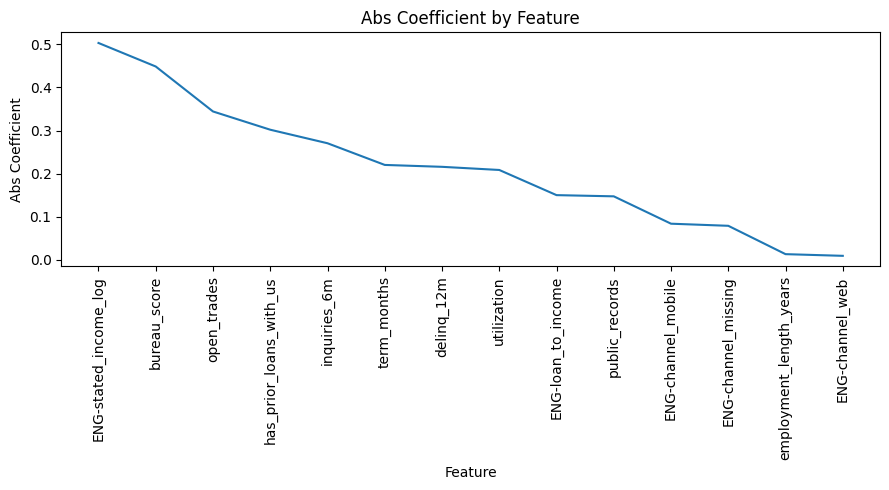

In [26]:
x = df_coef['feature']
y = df_coef['coef_abs']

fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Abs Coefficient by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Abs Coefficient')
ax.plot(x, y)

plt.xticks(rotation=90)   
plt.tight_layout()        
plt.show()

#### Reverse stepwise feature removal

In [27]:
df_coef.sort_values(by='coef_abs', ascending=True, inplace=True)

# get list of cols in the model
list_cols_model = list(cls_model_inference.feature_names_in_)

list_dict_row = []
for feature in df_coef['feature']:
    print(f'Removing {feature}')
    # rm feature from list
    list_cols_model = [col for col in list_cols_model if col != feature]
    # fit
    try:
        dict_row = fit_logistic_model(
            X_train=X_train[list_cols_model],
            y_train=y_train,
            X_valid=X_valid[list_cols_model],
            y_valid=y_valid,
            X_test=X_test[list_cols_model],
            y_test=y_test,
        )
    except (IndexError, ValueError):
        continue
    # append
    list_dict_row.append(dict_row)
    print()
# concat
df_tuning = pd.DataFrame(list_dict_row)
# sort
df_tuning.sort_values(by='flt_pr_auc_valid', ascending=False, inplace=True)
# show
df_tuning

Removing ENG-channel_web

Removing employment_length_years

Removing ENG-channel_missing

Removing ENG-channel_mobile

Removing public_records

Removing ENG-loan_to_income

Removing utilization

Removing delinq_12m

Removing term_months

Removing inquiries_6m

Removing has_prior_loans_with_us

Removing open_trades

Removing bureau_score

Removing ENG-stated_income_log


,flt_roc_auc_train,flt_roc_auc_valid,flt_roc_auc_test,flt_pr_auc_train,flt_pr_auc_valid,flt_pr_auc_test,cls_model_inference
2,0.774198,0.759718,0.757770,0.413553,0.397449,0.394885,LogisticRegression(random_state=42)
1,0.774208,0.759732,0.757795,0.413541,0.397437,0.394913,LogisticRegression(random_state=42)
0,0.774265,0.759677,0.757880,0.413475,0.397386,0.395094,LogisticRegression(random_state=42)
3,0.774057,0.759316,0.758201,0.413312,0.396824,0.394888,LogisticRegression(random_state=42)
4,0.773460,0.756563,0.756601,0.405820,0.386811,0.390342,LogisticRegression(random_state=42)
5,0.772236,0.754504,0.756146,0.404954,0.381345,0.390956,LogisticRegression(random_state=42)
6,0.769295,0.749949,0.751454,0.395693,0.373014,0.377978,LogisticRegression(random_state=42)
7,0.762785,0.747411,0.743148,0.385130,0.366881,0.366557,LogisticRegression(random_state=42)
11,0.769869,0.769117,0.761384,0.378546,0.366249,0.358612,LogisticRegression(random_state=42)
8,0.758779,0.742497,0.737723,0.377141,0.360521,0.357578,LogisticRegression(random_state=42)


#### Get best model

In [28]:
cls_model_inference = df_tuning['cls_model_inference'].iloc[0]

#### Get N features

In [29]:
list_feats_final = list(cls_model_inference.feature_names_in_)
int_n_features = len(list_feats_final)
print(f'N Features: {int_n_features}')

N Features: 11


#### Get optimized metrics

In [30]:
for col in ['flt_roc_auc_train','flt_roc_auc_valid','flt_pr_auc_train','flt_pr_auc_valid']:
    flt_metric = df_tuning[col].iloc[0]
    print(f'{col}: {flt_metric:0.4f}')

flt_roc_auc_train: 0.7742
flt_roc_auc_valid: 0.7597
flt_pr_auc_train: 0.4136
flt_pr_auc_valid: 0.3974


#### Get coefficients

In [31]:
coef = cls_model_inference.coef_.ravel()
df_coef = pd.DataFrame({
    "feature": cls_model_inference.feature_names_in_,
    "coef": coef
})
# abs
df_coef['coef_abs'] = df_coef['coef'].abs()
# sort
df_coef.sort_values("coef_abs", ascending=False, inplace=True)
# show
df_coef

,feature,coef,coef_abs
8,ENG-stated_income_log,-0.503095,0.503095
2,bureau_score,-0.448115,0.448115
3,open_trades,-0.343903,0.343903
1,has_prior_loans_with_us,-0.306424,0.306424
6,inquiries_6m,0.270452,0.270452
0,term_months,-0.220229,0.220229
4,delinq_12m,0.215789,0.215789
5,utilization,0.208908,0.208908
9,ENG-loan_to_income,-0.150071,0.150071
7,public_records,0.147652,0.147652


#### Plot it

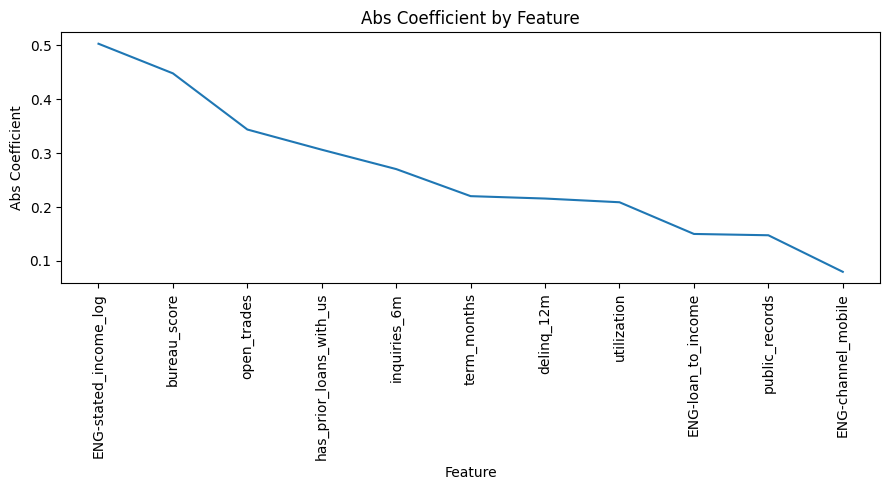

In [32]:
x = df_coef['feature']
y = df_coef['coef_abs']

fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Abs Coefficient by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Abs Coefficient')
ax.plot(x, y)

plt.xticks(rotation=90)   
plt.tight_layout()        
plt.show()